# Development of CNNs Models with Log-Mel Spectrogram and MFCC as their input features:

## Imports:

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import random

In [3]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## Geral:

In [4]:
SAMPLE_RATE = 16000
N_FFT = 512
HOP_LENGTH = 160
N_MELS = 64
BATCH_SIZE = 64

CLASS_NAMES = np.array(['go', 'no', 'off', 'on', 'stop', '_unknown_'])
NUM_CLASSES = len(CLASS_NAMES)

AUTOTUNE = tf.data.AUTOTUNE

DATASET_PATH = "../Datasets/KWS/KWS/dataset_augmented/"

In [5]:
def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    label = parts[-2]
    return tf.argmax(label == CLASS_NAMES)

In [6]:
def process_audio_log_mel(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])

    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]

    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz= 20,
        upper_edge_hertz= SAMPLE_RATE / 2
    )

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    means = tf.math.reduce_mean(log_mel_spectrogram)
    stds = tf.math.reduce_std(log_mel_spectrogram)

    log_mel_spectrogram = (log_mel_spectrogram - means) / stds

    return tf.expand_dims(log_mel_spectrogram, -1)

In [7]:
def load_data_log_mel(file_path):
    label = get_label(file_path)
    spectrogram = process_audio_log_mel(file_path)
    return spectrogram, label

In [8]:
def process_audio_MFCC(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio = audio[:SAMPLE_RATE]
    audio = tf.pad(audio, [[0, SAMPLE_RATE - tf.shape(audio)[0]]])

    stft = tf.signal.stft(audio, frame_length=N_FFT, frame_step=HOP_LENGTH, fft_length=N_FFT)
    spectrogram = tf.abs(stft)

    num_spectrogram_bins = spectrogram.shape[-1]

    linear_to_mel_weight_matrix = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=N_MELS,
        num_spectrogram_bins=num_spectrogram_bins,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz= 20,
        upper_edge_hertz= SAMPLE_RATE / 2
    )

    mel_spectrogram = tf.tensordot(spectrogram, linear_to_mel_weight_matrix, 1)
    log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

    means = tf.math.reduce_mean(log_mel_spectrogram)
    stds = tf.math.reduce_std(log_mel_spectrogram)

    log_mel_spectrogram = (log_mel_spectrogram - means) / stds

    mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)[..., :13]

    return tf.expand_dims(mfccs, -1)

In [9]:
def load_data_MFCC(file_path):
    label = get_label(file_path)
    spectrogram = process_audio_MFCC(file_path)
    return spectrogram, label

In [11]:
train_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/train/*/*.wav")
val_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/validation/*/*.wav")
test_ds = tf.data.Dataset.list_files(f"{DATASET_PATH}/test/*/*.wav")

In [12]:
train_ds_log_mel = (train_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

train_ds_MFCC = (train_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_log_mel = (val_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds_MFCC = (val_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_log_mel = (test_ds
    .map(load_data_log_mel, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds_MFCC = (test_ds
    .map(load_data_MFCC, num_parallel_calls=AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

Input shape: (64, 97, 64, 1)
Label shape: (64,)


2025-12-02 09:54:38.757764: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


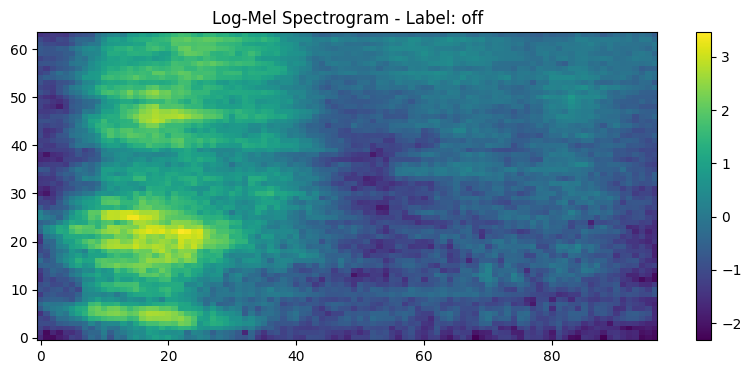

2025-12-02 09:54:38.838518: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
for spec, label in train_ds_log_mel.take(1):
    input_shape_log_mel = spec[0].shape
    print("Input shape:", spec.shape)
    print("Label shape:", label.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spec[0], perm=[1, 0, 2])[:, :, 0], aspect='auto', origin='lower')
    plt.title(f"Log-Mel Spectrogram - Label: {CLASS_NAMES[label[0]]}")
    plt.colorbar()
    plt.show()

In [14]:
print("Log-Mel Spectrogram input shape:", input_shape_log_mel)

Log-Mel Spectrogram input shape: (97, 64, 1)


Input shape: (64, 97, 13, 1)
Label shape: (64,)


2025-12-02 09:54:42.404893: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


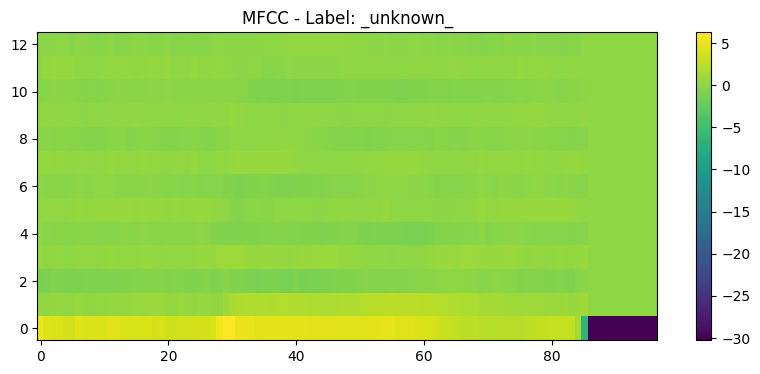

2025-12-02 09:54:42.468529: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
for spec, label in train_ds_MFCC.take(1):
    input_shape_MFCC = spec[0].shape
    print("Input shape:", spec.shape)
    print("Label shape:", label.shape)
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.transpose(spec[0], perm=[1, 0, 2])[:, :, 0], aspect='auto', origin='lower')
    plt.title(f"MFCC - Label: {CLASS_NAMES[label[0]]}")
    plt.colorbar()
    plt.show()

In [16]:
print("MFCC input shape:", input_shape_MFCC)

MFCC input shape: (97, 13, 1)


## Training:

### Log-Mel Spectrogram:

In [17]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
random.seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [18]:
model_log_mel = tf.keras.models.Sequential([
    # Input:
    tf.keras.layers.Input(input_shape_log_mel),

    # Bloco de Convolução 1
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten:
    tf.keras.layers.Flatten(),

    # Bloco Denso para classificação:
    tf.keras.layers.Dense(256),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model_log_mel.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 97, 64, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 97, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 97, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     3,145,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,293,638 (12.56 MB)

 Trainable params: 3,292,358 (12.56 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [19]:
model_log_mel.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [20]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

In [21]:
history_log_mel = model_log_mel.fit(train_ds_log_mel, validation_data=val_ds_log_mel, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


2025-12-02 09:54:55.590552: I external/local_xla/xla/service/service.cc:163] XLA service 0x77a294002990 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-12-02 09:54:55.590565: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-12-02 09:54:55.622001: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-12-02 09:54:55.815728: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91600
2025-12-02 09:54:55.863847: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 09:54:55.863881: I e

  16/2059 ━━━━━━━━━━━━━━━━━━━━ 24s 12ms/step - accuracy: 0.4177 - loss: 1.6053

I0000 00:00:1764680098.771636  111518 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2059/2059 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - accuracy: 0.8959 - loss: 0.2926 - val_accuracy: 0.9208 - val_loss: 0.2377 - learning_rate: 0.0010
Epoch 2/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9580 - loss: 0.1185 - val_accuracy: 0.9000 - val_loss: 0.3369 - learning_rate: 0.0010
Epoch 3/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9736 - loss: 0.0729 - val_accuracy: 0.9377 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 4/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9824 - loss: 0.0497 - val_accuracy: 0.9307 - val_loss: 0.2894 - learning_rate: 0.0010
Epoch 5/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9874 - loss: 0.0360 - val_accuracy: 0.9479 - val_loss: 0.2102 - learning_rate: 0.0010
Epoch 6/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9896 - loss: 0.0293 - val_accuracy: 0.9425 - val_loss: 0.2530 - learning_rate: 0.0010
Epoch 7/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0

### MFCC:

In [22]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
random.seed(42)
np.random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

In [23]:
model_MFCC = tf.keras.models.Sequential([
    # Input:
    tf.keras.layers.Input(input_shape_MFCC),

    # Bloco de Convolução 1
    tf.keras.layers.Conv2D(32, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 2
    tf.keras.layers.Conv2D(64, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Bloco de Convolução 3
    tf.keras.layers.Conv2D(128, kernel_size=(3, 3), padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    # Flatten:
    tf.keras.layers.Flatten(),

    # Bloco Denso para classificação:
    tf.keras.layers.Dense(128),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(64),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dense(len(CLASS_NAMES), activation='softmax')
])

model_MFCC.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 97, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 97, 13, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 97, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 6, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 6, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 6, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 48, 6, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 24, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 24, 3, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       196,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 299,718 (1.14 MB)

 Trainable params: 298,886 (1.14 MB)

 Non-trainable params: 832 (3.25 KB)

In [24]:
model_MFCC.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [25]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

In [26]:
history_MFCC = model_MFCC.fit(train_ds_MFCC, validation_data=val_ds_MFCC, callbacks=callbacks, epochs=100, verbose=1)

Epoch 1/100


2025-12-02 10:00:44.930203: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 10:00:44.930229: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 10:00:44.930257: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 10:00:44.930263: I external/l

2059/2059 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.8771 - loss: 0.3505 - val_accuracy: 0.8930 - val_loss: 0.3102 - learning_rate: 0.0010
Epoch 2/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9399 - loss: 0.1714 - val_accuracy: 0.9130 - val_loss: 0.2686 - learning_rate: 0.0010
Epoch 3/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9552 - loss: 0.1257 - val_accuracy: 0.9376 - val_loss: 0.1844 - learning_rate: 0.0010
Epoch 4/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9650 - loss: 0.0971 - val_accuracy: 0.9365 - val_loss: 0.1997 - learning_rate: 0.0010
Epoch 5/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9716 - loss: 0.0782 - val_accuracy: 0.9456 - val_loss: 0.1714 - learning_rate: 0.0010
Epoch 6/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9770 - loss: 0.0650 - val_accuracy: 0.9406 - val_loss: 0.1969 - learning_rate: 0.0010
Epoch 7/100
2059/2059 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9801 - loss:

## Testing:

### Log-Mel Spectrogram:

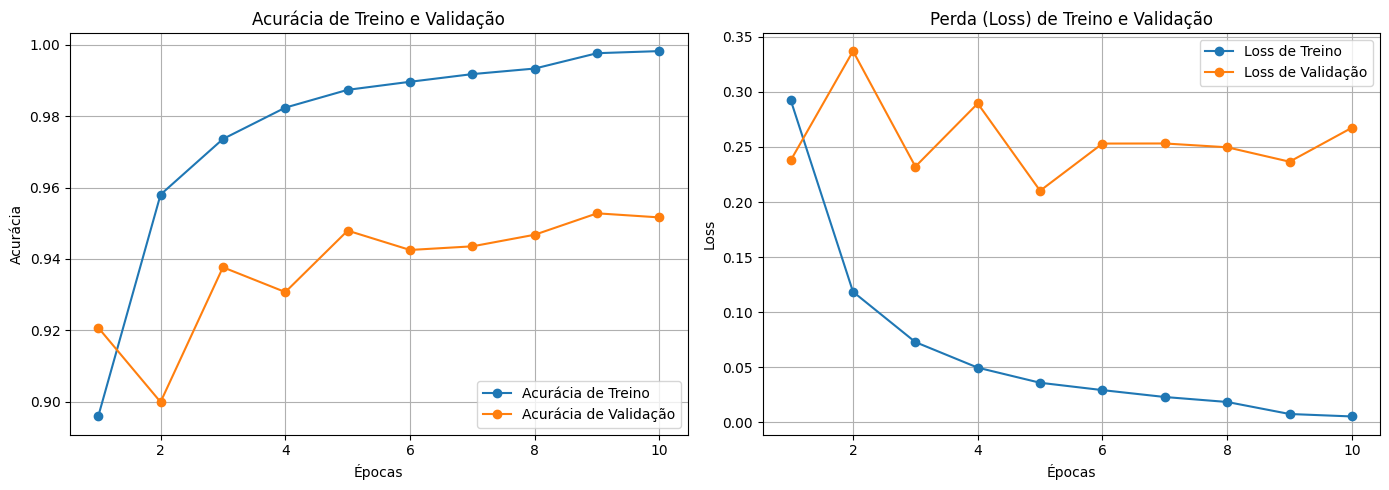

In [27]:
acc = history_log_mel.history['accuracy']
val_acc = history_log_mel.history['val_accuracy']
loss = history_log_mel.history['loss']
val_loss = history_log_mel.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [28]:
model_log_mel = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras')

y_pred_probs = model_log_mel.predict(test_ds_log_mel)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds_log_mel], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

60/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2025-12-02 10:01:41.074794: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 10:01:41.358028: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 8 bytes spill stores, 8 bytes spill loads



77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          go       0.95      0.83      0.89       402
          no       0.90      0.91      0.91       405
         off       0.93      0.93      0.93       402
          on       0.92      0.90      0.91       396
        stop       0.99      0.92      0.96       411
   _unknown_       0.95      0.97      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.94      0.91      0.92      4890
weighted avg       0.94      0.94      0.94      4890



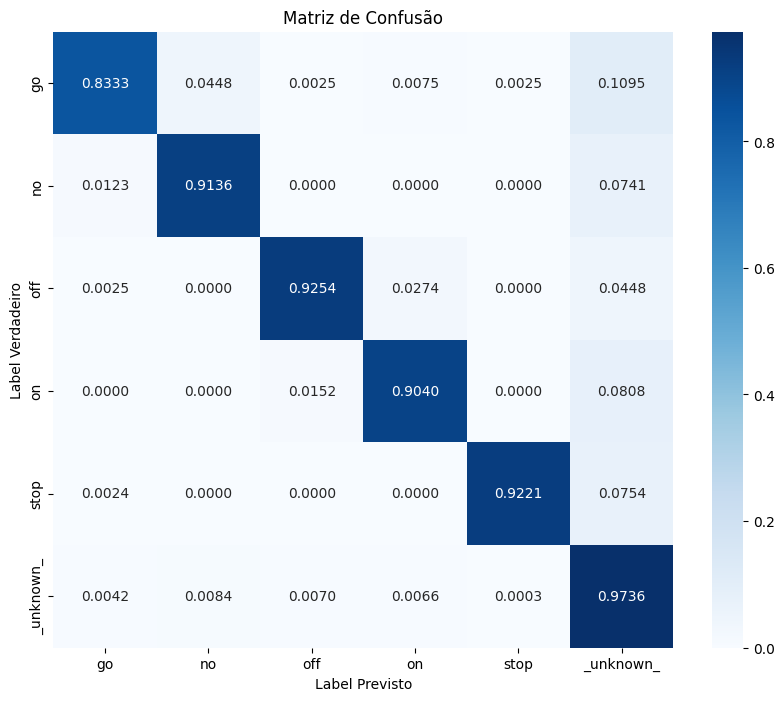

In [29]:
cm = confusion_matrix(y_true_indices, y_pred_indices)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

### MFCC:

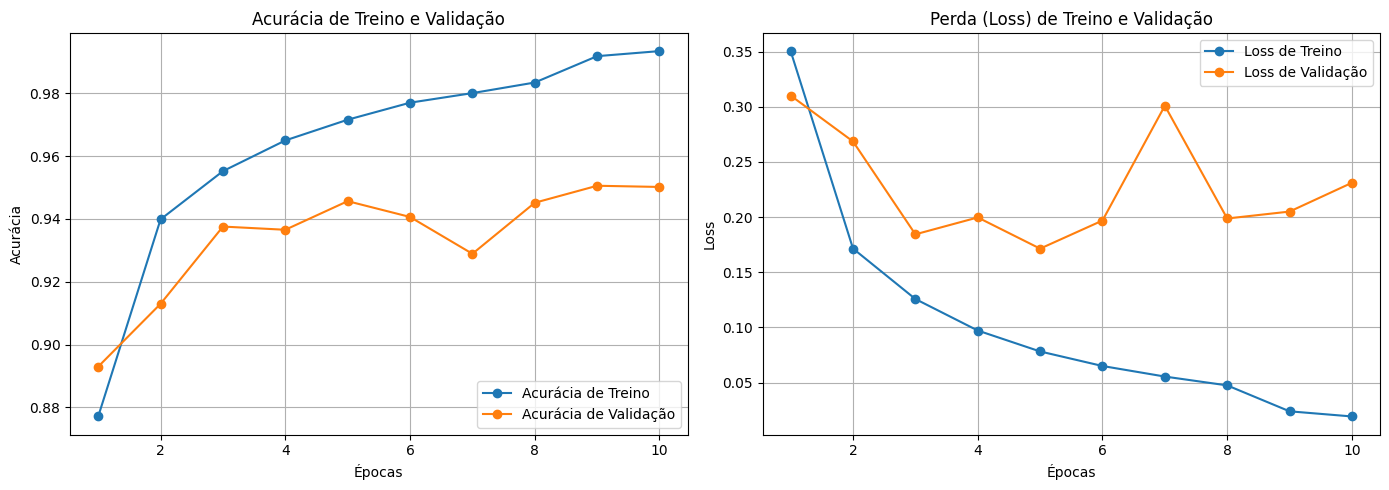

In [30]:
acc = history_MFCC.history['accuracy']
val_acc = history_MFCC.history['val_accuracy']
loss = history_MFCC.history['loss']
val_loss = history_MFCC.history['val_loss']

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, 'o-', label='Acurácia de Treino')
plt.plot(epochs_range, val_acc, 'o-', label='Acurácia de Validação')
plt.title('Acurácia de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.grid(True)
plt.legend(loc='lower right')
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'o-', label='Loss de Treino')
plt.plot(epochs_range, val_loss, 'o-', label='Loss de Validação')
plt.title('Perda (Loss) de Treino e Validação')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [31]:
model_MFCC = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras')

y_pred_probs = model_MFCC.predict(test_ds_MFCC)
y_pred_indices = np.argmax(y_pred_probs, axis=1)

y_true_indices = np.concatenate([y for x, y in test_ds_MFCC], axis=0)

print("\n--- Relatório de Classificação ---")
report = classification_report(y_true_indices, y_pred_indices, target_names=CLASS_NAMES)
print(report)

61/77 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

2025-12-02 10:01:57.983655: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-12-02 10:01:58.255193: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_169', 28 bytes spill stores, 28 bytes spill loads



77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

--- Relatório de Classificação ---
              precision    recall  f1-score   support

          go       0.92      0.85      0.89       402
          no       0.86      0.94      0.90       405
         off       0.93      0.88      0.90       402
          on       0.95      0.89      0.92       396
        stop       0.99      0.96      0.97       411
   _unknown_       0.95      0.97      0.96      2874

    accuracy                           0.94      4890
   macro avg       0.93      0.91      0.92      4890
weighted avg       0.94      0.94      0.94      4890



2025-12-02 10:01:58.665487: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


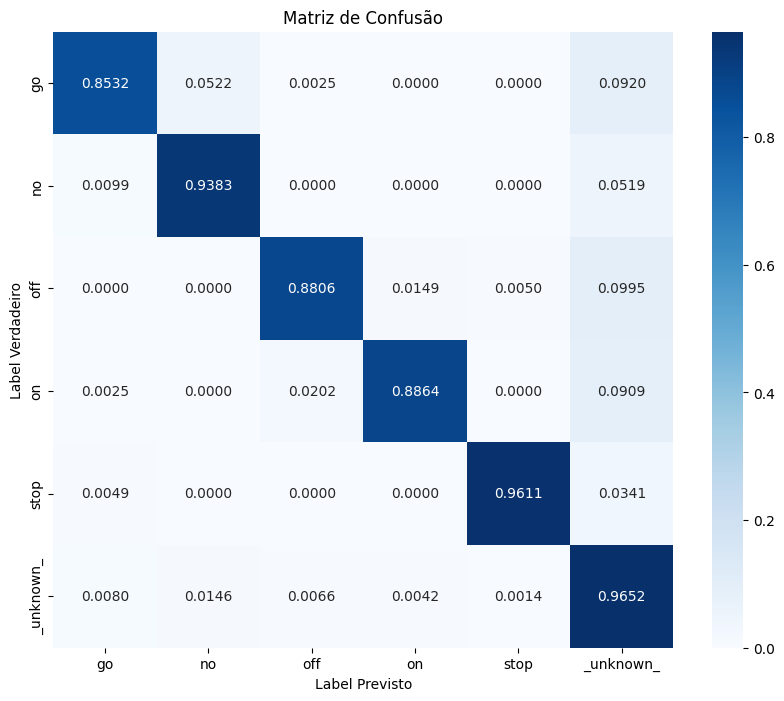

In [32]:
cm = confusion_matrix(y_true_indices, y_pred_indices)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Matriz de Confusão')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.show()

## Gerando modelo .tflite (float16):

### Log-Mel Spectrogram:

In [33]:
log_mel_model = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.keras')

class EndToEndModel(tf.Module):
    def __init__(self, model):
        self.model = model
        self.sample_rate = SAMPLE_RATE
        self.n_fft = N_FFT
        self.hop_length = HOP_LENGTH
        self.n_mels = N_MELS

        self.mel_matrix = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.n_mels,
            num_spectrogram_bins=self.n_fft // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=20,
            upper_edge_hertz=self.sample_rate / 2
        )

    @tf.function(input_signature=[tf.TensorSpec(shape=[1, 16000], dtype=tf.float32)])
    def __call__(self, audio):
        waveform = audio[0, :self.sample_rate]

        stft = tf.signal.stft(waveform, frame_length=self.n_fft, frame_step=self.hop_length, fft_length=self.n_fft)
        spectrogram = tf.abs(stft)
        mel_spectrogram = tf.tensordot(spectrogram, self.mel_matrix, 1)
        log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

        means = tf.math.reduce_mean(log_mel_spectrogram)
        stds = tf.math.reduce_std(log_mel_spectrogram)

        stds = tf.where(stds < 1e-6, 1e-6, stds)

        log_mel_spectrogram = (log_mel_spectrogram - means) / stds

        model_input = tf.expand_dims(log_mel_spectrogram, axis=-1)
        model_input = tf.expand_dims(model_input, axis=0)
        return self.model(model_input)
        
end_to_end_wrapper = EndToEndModel(log_mel_model)
converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [end_to_end_wrapper.__call__.get_concrete_function()]
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.tflite', 'wb') as f:
    f.write(tflite_model)

I0000 00:00:1764680538.919991  111387 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1764680538.920095  111387 single_machine.cc:376] Starting new session
I0000 00:00:1764680538.924613  111387 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9874 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
W0000 00:00:1764680539.362882  111387 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764680539.362898  111387 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-12-02 10:02:19.622789: I tensorflow/compiler/mlir/lite/flatbuffer_export.cc:4150] Estimated count of arithmetic ops: 187.725 M  ops, equivalently 93.862 M  MACs


### MFCC:

In [38]:
MFCC_model = tf.keras.models.load_model('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.keras')

class EndToEndModel(tf.Module):
    def __init__(self, model):
        self.model = model
        self.sample_rate = SAMPLE_RATE
        self.n_fft = N_FFT
        self.hop_length = HOP_LENGTH
        self.n_mels = N_MELS

        self.mel_matrix = tf.signal.linear_to_mel_weight_matrix(
            num_mel_bins=self.n_mels,
            num_spectrogram_bins=self.n_fft // 2 + 1,
            sample_rate=self.sample_rate,
            lower_edge_hertz=20,
            upper_edge_hertz=self.sample_rate / 2
        )

    @tf.function(input_signature=[tf.TensorSpec(shape=[1, 16000], dtype=tf.float32)])
    def __call__(self, audio):
        waveform = audio[0, :self.sample_rate]

        stft = tf.signal.stft(waveform, frame_length=self.n_fft, frame_step=self.hop_length, fft_length=self.n_fft)
        spectrogram = tf.abs(stft)
        mel_spectrogram = tf.tensordot(spectrogram, self.mel_matrix, 1)
        log_mel_spectrogram = tf.math.log(mel_spectrogram + 1e-6)

        means = tf.math.reduce_mean(log_mel_spectrogram)
        stds = tf.math.reduce_std(log_mel_spectrogram)

        stds = tf.where(stds < 1e-6, 1e-6, stds)

        log_mel_spectrogram = (log_mel_spectrogram - means) / stds

        mfccs = tf.signal.mfccs_from_log_mel_spectrograms(log_mel_spectrogram)[..., :13]

        model_input = tf.expand_dims(mfccs, axis=-1)
        model_input = tf.expand_dims(model_input, axis=0)
        return self.model(model_input)
        
end_to_end_wrapper = EndToEndModel(MFCC_model)
converter = tf.lite.TFLiteConverter.from_concrete_functions(
    [end_to_end_wrapper.__call__.get_concrete_function()]
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS
]

#converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.tflite', 'wb') as f:
    f.write(tflite_model)

I0000 00:00:1764680628.473588  111387 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 1
I0000 00:00:1764680628.473663  111387 single_machine.cc:376] Starting new session
I0000 00:00:1764680628.478088  111387 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9874 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:01:00.0, compute capability: 8.9
W0000 00:00:1764680628.596280  111387 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1764680628.596297  111387 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2025-12-02 10:03:48.631558: W tensorflow/compiler/mlir/lite/flatbuffer_export.cc:4082] TFLite interpreter needs to link Flex delegate in order to run the model since it contains the following Select TFop(s):
Flex ops: FlexStridedSlice
Details:
	tf.StridedSlice(tensor<97x65xcomplex<f32>>, tensor<2xi32>, tensor<2xi32>, tensor<2xi32>) -> (tensor<97x64xcomplex

## Testing .tflite models:

### Log-Mel Spectrogram:

In [39]:
TFLITE_MODEL_PATH = Path('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.tflite')

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("\n--- Detalhes do Modelo TFLite ---")
print(f"Entrada (Shape): {input_details['shape']}")
print(f"Entrada (Tipo): {input_details['dtype']}")
print(f"Saída (Shape): {output_details['shape']}")
print(f"Saída (Tipo): {output_details['dtype']}")

Carregando modelo TFLite de: ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_log_mel.tflite

--- Detalhes do Modelo TFLite ---
Entrada (Shape): [    1 16000]
Entrada (Tipo): <class 'numpy.float32'>
Saída (Shape): [1 6]
Saída (Tipo): <class 'numpy.float32'>


/home/rolds/Documents/venvs/tensorflow_venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [40]:
def load_wav_for_test(file_path):
    audio_binary = tf.io.read_file(file_path)
    audio, _ = tf.audio.decode_wav(audio_binary, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    audio_len = tf.shape(audio)[0]
    if audio_len > SAMPLE_RATE:
        audio = audio[:SAMPLE_RATE]
    else:
        audio = tf.pad(audio, [[0, SAMPLE_RATE - audio_len]])

    audio = tf.expand_dims(audio, axis=0)

    return audio, get_label(file_path)

test_ds_lite = test_ds.map(load_wav_for_test).batch(1)

y_true = []
y_pred = []

print("Iniciando avaliação no dataset de teste...")
for data_batch, labels_batch in test_ds_lite:
    for i in range(data_batch.shape[0]):
        sample_data = data_batch[i]
        input_tensor = sample_data.numpy().astype(input_details['dtype'])
        interpreter.set_tensor(input_details['index'], input_tensor)
        interpreter.invoke()
        output_data = interpreter.get_tensor(output_details['index'])
        predicted_label_index = np.argmax(output_data)
        y_pred.append(predicted_label_index)
        y_true.append(labels_batch[i].numpy())
        
print("\nAvaliação concluída.")

Iniciando avaliação no dataset de teste...

Avaliação concluída.


In [42]:
print("\n--- Relatório de Classificação ---\n")
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES)
print(report)


--- Relatório de Classificação ---

              precision    recall  f1-score   support

          go       0.93      0.53      0.68       402
          no       0.89      0.61      0.73       405
         off       0.86      0.87      0.87       402
          on       0.92      0.72      0.81       396
        stop       0.98      0.87      0.93       411
   _unknown_       0.85      0.97      0.90      2874

    accuracy                           0.87      4890
   macro avg       0.91      0.76      0.82      4890
weighted avg       0.88      0.87      0.86      4890



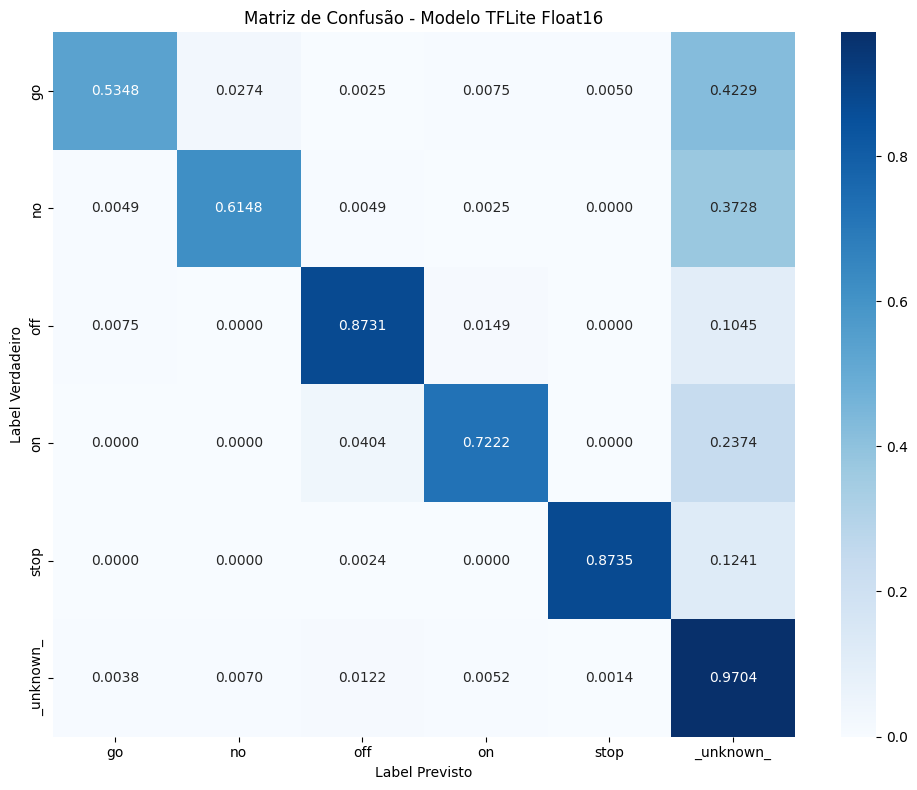

In [43]:
cm = confusion_matrix(y_true, y_pred)
row_sums = cm.sum(axis=1, keepdims=True)
cm_normalized = cm.astype('float') / row_sums

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.4f',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title('Matriz de Confusão - Modelo TFLite Float16')
plt.ylabel('Label Verdadeiro')
plt.xlabel('Label Previsto')
plt.tight_layout()
plt.show()

### MFCC:

In [46]:
TFLITE_MODEL_PATH = Path('../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.tflite')

print("Versão do TensorFlow:", tf.__version__)

print(f"Carregando modelo TFLite de: {TFLITE_MODEL_PATH}")

# 1. Criação do Interpretador: O TensorFlow completo já inclui o suporte Flex.
interpreter = tf.lite.Interpreter(model_path=str(TFLITE_MODEL_PATH))

# 2. Alocação de Tensores: Este passo que falhava antes, agora deve funcionar.
try:
    interpreter.allocate_tensors()
except RuntimeError as e:
    print(f"\nERRO: A alocação de tensores falhou novamente. ({e})")
    print("Isso indica que o pacote do TensorFlow instalado ainda não contém o suporte ao Flex Delegate.")
    # Se falhar aqui, o pacote instalado pode ser uma versão incompleta ou incompatível.
else:
    # 3. Exibição dos Detalhes (Continuação do seu código original)
    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    print("\n✅ Sucesso! O interpretador alocou os tensores.")
    print("\n--- Detalhes do Modelo TFLite ---")
    print(f"Entrada (Shape): {input_details['shape']}")
    print(f"Entrada (Tipo): {input_details['dtype']}")
    print(f"Saída (Shape): {output_details['shape']}")
    print(f"Saída (Tipo): {output_details['dtype']}")

Versão do TensorFlow: 2.20.0
Carregando modelo TFLite de: ../Projects/KWS-rasp-zero/KWS-RaspZero2W/Log_mel_&_MFCC/models/model_MFCC.tflite

ERRO: A alocação de tensores falhou novamente. (Select TensorFlow op(s), included in the given model, is(are) not supported by this interpreter. Make sure you apply/link the Flex delegate before inference. For the Android, it can be resolved by adding "org.tensorflow:tensorflow-lite-select-tf-ops" dependency. See instructions: https://www.tensorflow.org/lite/guide/ops_selectNode number 24 (FlexStridedSlice) failed to prepare.)
Isso indica que o pacote do TensorFlow instalado ainda não contém o suporte ao Flex Delegate.


/home/rolds/Documents/venvs/tensorflow_venv/lib/python3.10/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
